
# Icebergs (openberg)


In [1]:
from opendrift.models.openberg import OpenBerg
from datetime import datetime,timedelta, timezone

In [2]:
o = OpenBerg(loglevel=20)

11:52:52 INFO    opendrift:568: OpenDriftSimulation initialised (version 1.14.9)


In [3]:
# The user can overwrite the default setup using set_config method
o.set_config('drift:vertical_profile', False) # use surface currents for this test

o.add_readers_from_list([
        'https://thredds.met.no/thredds/dodsC/cmems/topaz6/dataset-topaz6-arc-15min-3km-be.ncml',
        'https://pae-paha.pacioos.hawaii.edu/thredds/dodsC/ncep_global/NCEP_Global_Atmospheric_Model_best.ncd'])


## Seed and Run

Run parameters have been adjusted to match with official OpenDrift demonstration and computation performances
    - simulation starting on 2024-10-31 15:122
    - 3 days simulation every 6hrs 
    - 15 particles (instead of 100)

In [4]:
o.seed_elements(lon= -56,lat= 72,time=datetime(2024,10,31,15,12,0), #datetime.now(timezone.utc),
                number=100, radius=500,
                sail=10,draft=50,length=90,width=40)

11:52:52 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
11:52:56 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
11:52:56 INFO    opendrift.models.basemodel.environment:230: 	x_sea_water_velocity: 0.000000
11:52:56 INFO    opendrift.models.basemodel.environment:230: 	y_sea_water_velocity: 0.000000
11:52:56 INFO    opendrift.models.basemodel.environment:230: 	sea_floor_depth_below_sea_level: 10000.000000
11:52:56 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
11:52:56 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_x_slope: 0.000000
11:52:56 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_y_slope: 0.000000
11:52:56 INFO    opendrift.models.basemodel.environment:230: 	x_wind: 0.000000
11:52:56 INFO    opendrift.models.basemodel.environment:230: 	y_wind: 0.000000
11:52:56 INFO    opendrift.models.

In [5]:
o.run(duration=timedelta(days=3))#,time_step=timedelta(minutes=15))

11:53:03 INFO    opendrift:1839: Storing previous values of element property lon because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
11:53:03 INFO    opendrift:1839: Storing previous values of element property lat because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
11:53:03 INFO    opendrift:947: Using existing reader for land_binary_mask to move elements to ocean
11:53:03 INFO    opendrift:978: All points are in ocean
11:53:03 INFO    opendrift:2136: 2024-10-31 15:12:00 - step 1 of 72 - 100 active elements (0 deactivated)
11:53:03 INFO    opendrift.readers:64: Opening file with xr.open_dataset
11:53:06 INFO    opendrift.readers.reader_netCDF_CF_generic:340: Detected dimensions: {'x': 'x', 'y': 'y', 'time': 'time'}
11:53:06 INFO    opendrift.readers:64: Opening file with xr.open_dataset
11:53:09 INFO    opendrift

<xarray.Dataset> Size: 1MB
Dimensions:                                   (trajectory: 100, time: 73)
Coordinates:
  * trajectory                                (trajectory) int64 800B 0 1 ... 99
  * time                                      (time) datetime64[us] 584B 2024...
Data variables: (12/39)
    status                                    (trajectory, time) float32 29kB ...
    moving                                    (trajectory, time) float32 29kB ...
    age_seconds                               (trajectory, time) float32 29kB ...
    origin_marker                             (trajectory, time) float32 29kB ...
    lon                                       (trajectory, time) float32 29kB ...
    lat                                       (trajectory, time) float32 29kB ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 29kB ...
    sea_ice_area_fraction                     (trajectory, time) float32 29kB ...
    sea_ice_thickness                         (trajectory, time) float32 29kB ...
    sea_ice_x_velocity                        (trajectory, time) float32 29kB ...
    sea_ice_y_velocity                        (trajectory, time) float32 29kB ...
    land_binary_mask                          (trajectory, time) float32 29kB ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

11:54:11 WARNING opendrift:2499: Plotting fast. This will make your plots less accurate.


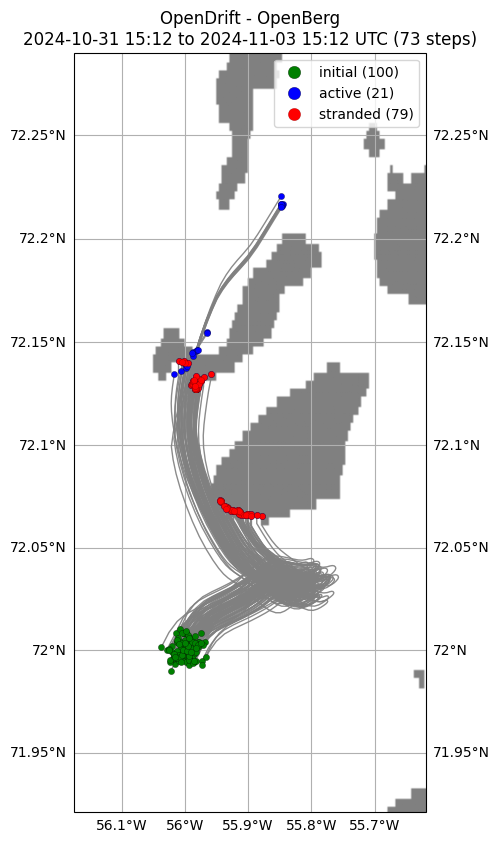

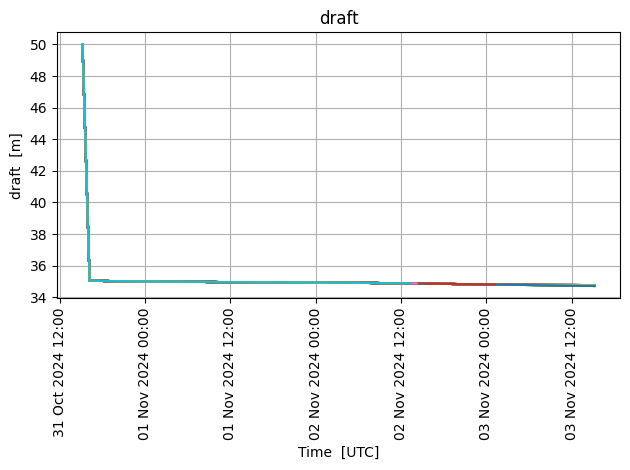

In [6]:
o.plot(fast=True)
o.plot_property('draft')